In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import os
import cv2

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
X_test shape: (10000, 28, 28)
y_test shape: (10000,)
(28, 28)
5


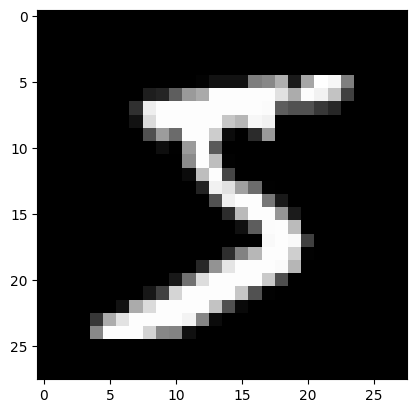

In [26]:
dataset = tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test) = dataset.load_data()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print(X_train[0].shape)
plt.imshow(X_train[0], cmap='gray')
print(y_train[0])
X_train=X_train/255.0
X_test=X_test/255.0

In [27]:
X_train_flat=X_train.reshape(X_train.shape[0], 28*28)
print(X_train_flat.shape)
X_test_flat=X_test.reshape(X_test.shape[0], 28*28)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense


In [87]:
model=Sequential([
    Dense(128, activation='relu', input_shape=(28*28,)),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

In [88]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer='adam', metrics=['accuracy'])

In [89]:
model.fit(X_train_flat,y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 697us/step - accuracy: 0.9293 - loss: 0.2420
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 685us/step - accuracy: 0.9677 - loss: 0.1048
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 704us/step - accuracy: 0.9784 - loss: 0.0715
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 744us/step - accuracy: 0.9827 - loss: 0.0550
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 803us/step - accuracy: 0.9863 - loss: 0.0438
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 710us/step - accuracy: 0.9881 - loss: 0.0363
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 779us/step - accuracy: 0.9904 - loss: 0.0284
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 782us/step - accuracy: 0.9922 - loss: 0.0238
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 849us/step - accuracy: 0.9924 - loss: 0.0231
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 765us/step - accuracy: 0.9931 - loss: 0.0201


In [90]:
predictions=model.predict(X_test_flat)
print(predictions[0])
print(np.argmax(predictions[0]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[8.7538687e-09 5.4930588e-08 3.2193890e-07 9.1202315e-07 1.3563487e-11
 7.7662078e-11 4.8309464e-12 9.9999809e-01 1.8822520e-08 5.1446870e-07]
7


In [91]:
model.evaluate(X_test_flat, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 372us/step - accuracy: 0.9745 - loss: 0.1053


[0.10534099489450455, 0.9745000004768372]

0


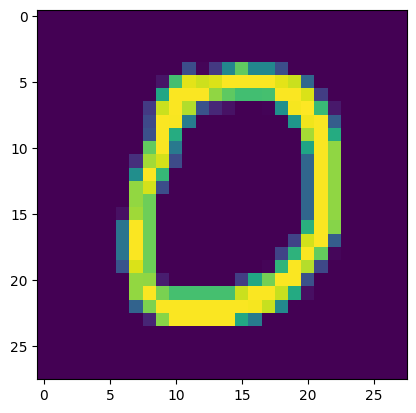

In [104]:
plt.imshow(X_test[10])
print(y_test[10])


In [93]:
predict=model.predict(X_test_flat[10].reshape(1, 28*28))
print(np.argmax(predict[0]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
0


(28, 28)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
7


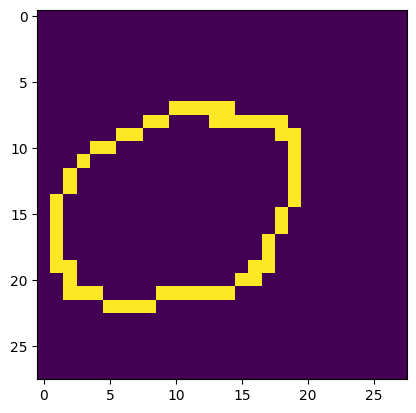

In [108]:
img=cv2.imread('Handwritten_digits/images/sample10.png', cv2.IMREAD_GRAYSCALE)
print(img.shape)
plt.imshow(img)
img=img/255.0
img_flat=img.reshape(1, 28*28)
predict=model.predict(img_flat)
print(np.argmax(predict[0]))

In [53]:
os.getcwd()

'/Users/priyanshnandan/Codes/ML/NeuralNetworks'